In [2]:
import numpy as np
import pandas as pd
import yfinance as yf

data = yf.download("SLV", start="2019-01-01", end="2026-03-31")
data


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SLV,SLV,SLV,SLV,SLV
Date,,,,,
2019-01-02,14.560000,14.660000,14.450000,14.460000,12310400
2019-01-03,14.750000,14.790000,14.630000,14.690000,12933200
2019-01-04,14.730000,14.790000,14.630000,14.730000,17854300
2019-01-07,14.670000,14.780000,14.660000,14.760000,7432300
2019-01-08,14.690000,14.730000,14.640000,14.650000,6776400
...,...,...,...,...,...
2026-03-24,62.950001,63.689999,61.270000,61.619999,48268000
2026-03-25,65.209999,66.400002,64.480003,66.040001,38165900


In [3]:
daily_return = data["Close"].pct_change()
daily_return

Ticker,SLV
Date,
2019-01-02,NaN
2019-01-03,0.013049
2019-01-04,-0.001356
2019-01-07,-0.004073
2019-01-08,0.001363
...,...
2026-03-24,0.007684
2026-03-25,0.035901
2026-03-26,-0.068088


In [4]:
monthly_ohlc = data["Close"].resample("ME").ohlc()
monthly_ohlc

Ticker            SLV                                  
                 open        high        low      close
Date                                                   
2019-01-31  14.560000   15.050000  14.360000  15.050000
2019-02-28  14.920000   15.070000  14.590000  14.630000
2019-03-31  14.200000   14.560000  14.070000  14.180000
2019-04-30  14.150000   14.310000  13.910000  14.020000
2019-05-31  13.750000   13.980000  13.460000  13.650000
...               ...         ...        ...        ...
2025-11-30  43.759998   51.209999  42.740002  51.209999
2025-12-31  52.520000   71.120003  51.759998  64.419998
2026-01-31  65.750000  105.599998  65.750000  75.440002
2026-02-28  72.440002   84.989998  66.370003  84.989998
2026-03-31  81.570000   81.570000  60.770000  63.520000

[87 rows x 4 columns]

In [5]:
monthly_ohlc["return"] = monthly_ohlc["SLV"]["close"] / monthly_ohlc["SLV"]["open"] - 1
monthly_ohlc


Ticker            SLV                                      return
                 open        high        low      close          
Date                                                             
2019-01-31  14.560000   15.050000  14.360000  15.050000  0.033654
2019-02-28  14.920000   15.070000  14.590000  14.630000 -0.019437
2019-03-31  14.200000   14.560000  14.070000  14.180000 -0.001408
2019-04-30  14.150000   14.310000  13.910000  14.020000 -0.009187
2019-05-31  13.750000   13.980000  13.460000  13.650000 -0.007273
...               ...         ...        ...        ...       ...
2025-11-30  43.759998   51.209999  42.740002  51.209999  0.170247
2025-12-31  52.520000   71.120003  51.759998  64.419998  0.226580
2026-01-31  65.750000  105.599998  65.750000  75.440002  0.147376
2026-02-28  72.440002   84.989998  66.370003  84.989998  0.173247
2026-03-31  81.570000   81.570000  60.770000  63.520000 -0.221282

[87 rows x 5 columns]

In [6]:
grouped= monthly_ohlc["return"].groupby(monthly_ohlc.index.year).mean()
max_return = grouped.idxmax()
min_return = grouped.idxmin()
print(f"Max ret year: {max_return}, Min ret year: {min_return}")



Max ret year: 2025, Min ret year: 2021


In [7]:
daily_return[abs(daily_return)>0.02].count()

Ticker
SLV    424
dtype: int64

In [8]:
daily_return.describe()

Ticker,SLV
count,1819.000000
mean,0.001057
std,0.021938
min,-0.285403
25%,-0.008929
50%,0.001030
75%,0.011223
max,0.091429


Text(0, 0.5, 'Frequency')

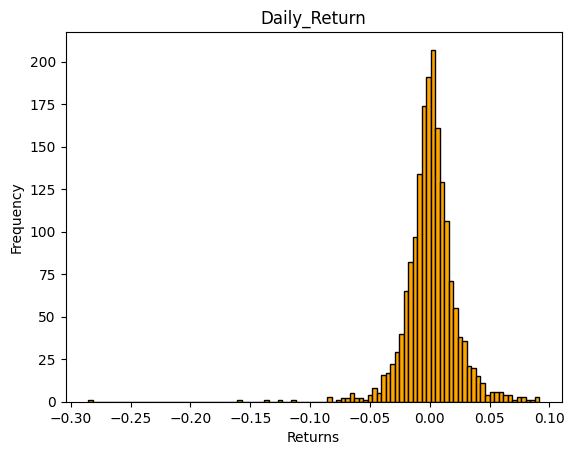

In [9]:
import matplotlib.pyplot as plt
plt.hist(daily_return, bins=100, edgecolor='black', color='orange')
plt.title("Daily_Return")
plt.xlabel("Returns")
plt.ylabel("Frequency")